In [1]:
from pathlib import Path
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt
import seaborn as sns
from io_utils import save_checkpoint

In [2]:
def load_and_annotate(
    sample_dir: str|Path,
    sample_id: str,
    condition: str,
) -> sc.AnnData:
    """
    Load a sample's 10x-style count matrix and add basic metadata.
    -----------
    Parameters
    -----------
        sample_dir: Path to the directory that contains matrix.mtx.gz.
        sample_id: Unique sample identifier, e.g., 'GSM5292146' in this study for a c9ALS dataset.
        condition: Biological condition, e.g., 'c9ALS' or 'Control'.
    --------
    Returns
    --------
        adata: AnnData object for that sample.
    """
    sample_dir = Path(sample_dir)
    
    if not sample_dir.exists():
        raise FileNotFoundError(f"Sample directory not found: {sample_dir}")

    adata = sc.read_10x_mtx(
        sample_dir,
        var_names="gene_symbols",
        cache=False 
    )
    adata.var_names_make_unique()

    adata.obs["sample"] = sample_id
    adata.obs["condition"] = condition

    print("Sample successfully loaded.")

    return adata


In [3]:
def compute_qc_metrics(adata: sc.AnnData) -> sc.AnnData:
    """
    Add QC gene flags and compute per-cell QC metrics.
    -----------
    Parameters
    -----------
        adata: AnnData object
    --------
    Returns
    --------
        adata, updated with:
            - adata.var["mt"]
            - adata.var["ribo"]
            - adata.var["hb"]
            - QC metrics in adata.obs via scanpy.pp.calculate_qc_metrics()
    """
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.match(r"^HB[ABDEG]")

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt", "ribo", "hb"],
        percent_top=[20],
        log1p=True,
        inplace=True,
    )

    print("QC metrics computed")

    return adata

In [4]:
def detect_low_quality_cells(
    adata: sc.AnnData,
    nmads_counts: int = 5,
    nmads_genes: int = 5,
    nmads_top20: int = 5,
    nmads_mt: int = 3,
    mt_percent_threshold: float = 5.0
) -> sc.AnnData:
    """
    Detect low-quality cells using MAD-based outlier logic and mitochondrial thresholds.
    -----------
    Parameters
    -----------
        adata: with QC annotations from compute_qc_metrics().
        nmads_counts: MAD threshold for log1p_total_counts.
        nmads_genes: MAD threshold for log1p_n_genes_by_counts.
        nmads_top20: MAD threshold for pct_counts_in_top_20_genes.
        nmads_mt: MAD threshold for pct_counts_mt.
        mt_percent_threshold: Hard threshold for pct_counts
    --------
    Returns
    --------
        adata, updated with 
            - adata.obs["outliers"]
            - adata.obs["mt_outliers"]
            - adata.obs["high_quality_cells"]
    """

    def is_outlier(metric: str, nmads: int) -> pd.Series:
        values = adata.obs[metric]
        median = np.median(values)
        mad = median_abs_deviation(values)

        lower_bound = median - (nmads * mad)
        upper_bound = median + (nmads * mad)

        return (values < lower_bound) | (values > upper_bound)

    adata.obs["outliers"] = (
        is_outlier("log1p_total_counts", nmads_counts) |
        is_outlier("log1p_n_genes_by_counts", nmads_genes) |
        is_outlier("pct_counts_in_top_20_genes", nmads_top20)
    )

    mt_outlier_mad = is_outlier("pct_counts_mt", nmads_mt)
    mt_outlier_percent = adata.obs["pct_counts_mt"] > mt_percent_threshold

    adata.obs["mt_outliers"] = mt_outlier_mad | mt_outlier_percent

    adata.obs["high_quality_cells"] = (~adata.obs["outliers"]) & (~adata.obs["mt_outliers"])

    n_outliers = (~adata.obs.high_quality_cells).sum()
    print(f"Detection complete. Flagged {n_outliers} cells as low-quality.")

    return adata


In [5]:
def remove_low_quality_cells(adata: sc.AnnData) -> sc.AnnData:
    """
    Keep only cells where "high_quality_cells" == True.
    -----------
    Parameters
    -----------
        adata: AnnData object that has been annotated by detect_low_quality_cells().
    --------
    Returns
    --------
        adata_filtered: AnnData object containing only high-quality cells.
    """

    if "high_quality_cells" not in adata.obs.columns:
        raise KeyError(
            "'high_quality_cells' not found in adata.obs."
            "Make sure of running detect_low_quality_cells() first."
        )
    n_before = adata.n_obs
    adata_filtered = adata[adata.obs["high_quality_cells"]].copy()
    n_after = adata_filtered.n_obs
    n_removed = n_before - n_after
    print(
        f"Low-quality cells removed."
        f"Cells before: {n_before}, after: {n_after}, removed: {n_removed}."
    )
    return adata_filtered

In [6]:
def freeze_raw_counts(adata: sc.AnnData) -> sc.AnnData:
    """
    Freeze the current count matrix as raw integer counts in a layer.
    This is typically called after low-quality-cell removal and before ambient RNA correction or any normalization and transformation.
    -----------
    Parameters
    -----------
        adata: AnnData object whose current 'X' is still the raw count data.
    --------
    Returns
    --------
        adata: AnnData object, updated with adata.layers["raw_counts"]
    """
    adata.layers["raw_counts"] = adata.X.copy()
    print("Raw counts frozen in adata.layers['raw_counts'].")
    
    return adata

Below is the C9ALS sample going through the pipeline.

In [8]:
adata_als = load_and_annotate(
    sample_dir="../results/40_starsolo_count/GSM5292146_c9ALS/Solo.out/GeneFull/filtered",
    sample_id="GSM5292146",
    condition="c9ALS",
)
adata_als = compute_qc_metrics(adata_als)
adata_als = detect_low_quality_cells(adata_als)

/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/scanpy/readwrite.py:570: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata = _read_10x_mtx(


Sample successfully loaded.
QC metrics computed
Detection complete. Flagged 2365 cells as low-quality.


In [9]:
adata_als_high_quality_cells = adata_als[adata_als.obs["high_quality_cells"]].copy()

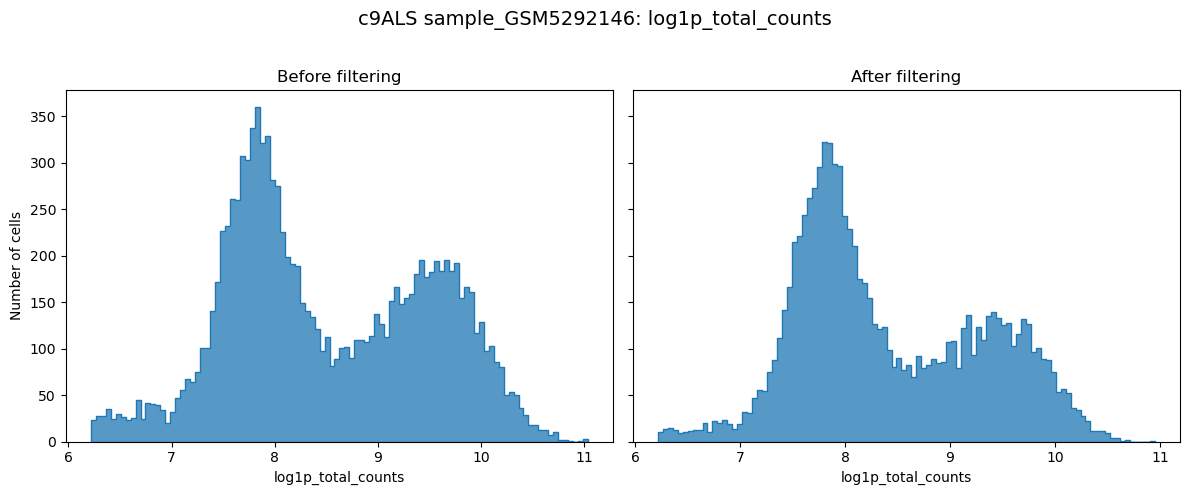

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
sns.histplot(
    data=adata_als.obs,
    x="log1p_total_counts",
    bins=100,
    element="step",
    ax=axes[0]
)
axes[0].set_title("Before filtering")
axes[0].set_xlabel("log1p_total_counts")
axes[0].set_ylabel("Number of cells")

sns.histplot(
    data=adata_als_high_quality_cells.obs,
    x="log1p_total_counts",
    bins=100,
    element="step",
    ax=axes[1]
)
axes[1].set_title("After filtering")
axes[1].set_xlabel("log1p_total_counts")
axes[1].set_ylabel("")

plt.suptitle(f"{adata_als.obs['condition'].iloc[0]} sample_{adata_als.obs['sample'].iloc[0]}: log1p_total_counts", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

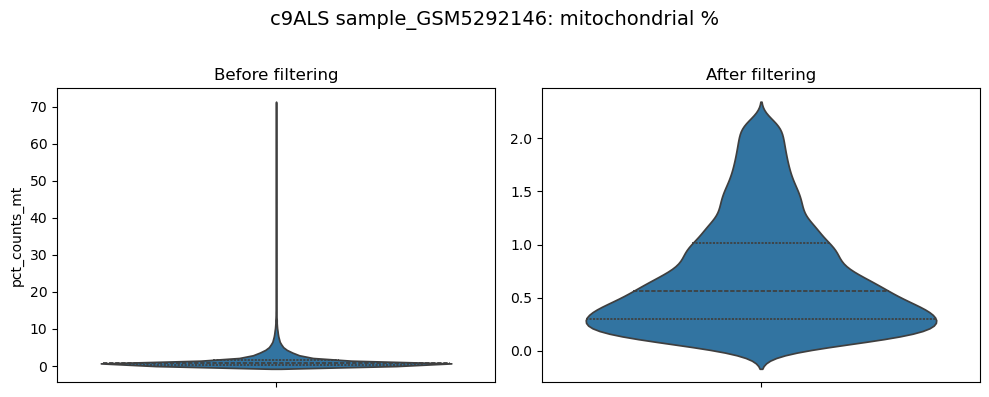

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=False)
sns.violinplot(
    data=adata_als.obs,
    y="pct_counts_mt",
    ax=axes[0],
    inner="quartile"
)
axes[0].set_title("Before filtering")
axes[0].set_xlabel("")
axes[0].set_ylabel("pct_counts_mt")

sns.violinplot(
    data=adata_als_high_quality_cells.obs,
    y="pct_counts_mt",
    ax=axes[1],
    inner="quartile"
)
axes[1].set_title("After filtering")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.suptitle(f"{adata_als.obs['condition'].iloc[0]} sample_{adata_als.obs['sample'].iloc[0]}: mitochondrial %", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

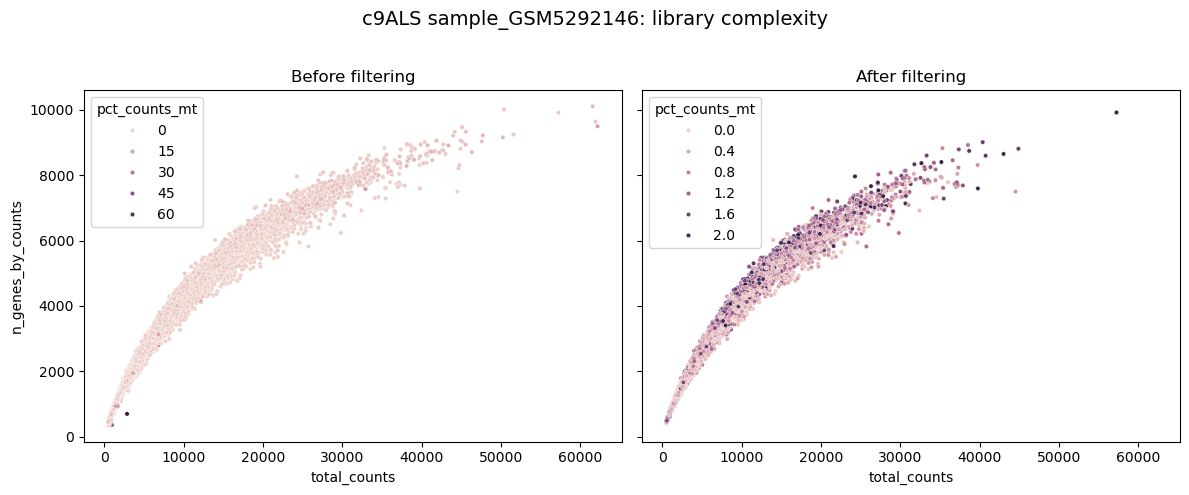

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(
    data=adata_als.obs,
    x="total_counts",
    y="n_genes_by_counts",
    hue="pct_counts_mt",
    s=10,
    ax=axes[0]
)
axes[0].set_title("Before filtering")

sns.scatterplot(
    data=adata_als_high_quality_cells.obs,
    x="total_counts",
    y="n_genes_by_counts",
    hue="pct_counts_mt",
    s=10,
    ax=axes[1]
)
axes[1].set_title("After filtering")

plt.suptitle(f"{adata_als.obs['condition'].iloc[0]} sample_{adata_als.obs['sample'].iloc[0]}: library complexity", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


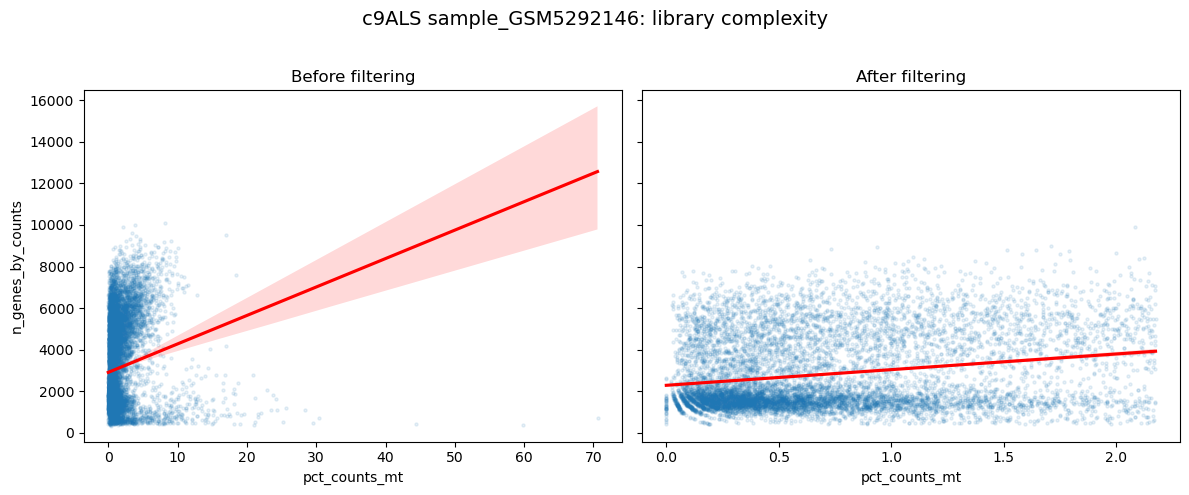

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

sns.regplot(
    data=adata_als.obs,
    x="pct_counts_mt",
    y="n_genes_by_counts",
    scatter_kws={"alpha":0.1, "s":5},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("Before filtering")
axes[0].set_xlabel("pct_counts_mt")
axes[0].set_ylabel("n_genes_by_counts")

sns.regplot(
    data=adata_als_high_quality_cells.obs,
    x="pct_counts_mt",
    y="n_genes_by_counts",
    scatter_kws={"alpha":0.1, "s":5},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title("After filtering")
axes[1].set_xlabel("pct_counts_mt")
axes[1].set_ylabel("")

plt.suptitle(f"{adata_als.obs['condition'].iloc[0]} sample_{adata_als.obs['sample'].iloc[0]}: library complexity", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
del adata_als_high_quality_cells
adata_als_high_quality_cells = remove_low_quality_cells(adata_als)

adata_als_high_quality_cells = freeze_raw_counts(adata_als_high_quality_cells)

save_checkpoint(adata_als_high_quality_cells,
                "../data/processed", 
                "low_quality_filtered") 

Low-quality cells removed.Cells before: 11533, after: 9168, removed: 2365.
Raw counts frozen in adata.layers['raw_counts'].
Checkpoint saved: ../data/processed/c9ALS_GSM5292146_low_quality_filtered.h5ad


PosixPath('../data/processed/c9ALS_GSM5292146_low_quality_filtered.h5ad')

Below is the Ctrl sample going through the pipeline.

In [13]:
adata_ctrl = load_and_annotate(
    sample_dir="../results/40_starsolo_count/GSM5292174_PN/Solo.out/GeneFull/filtered",
    sample_id="GSM5292174",
    condition="Control",
)
adata_ctrl = compute_qc_metrics(adata_ctrl)
adata_ctrl = detect_low_quality_cells(adata_ctrl)

/Users/wangj/Documents/Computational Biology/Projects/C9_Multiomics/c9_env/lib/python3.11/site-packages/scanpy/readwrite.py:570: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata = _read_10x_mtx(


Sample successfully loaded.
QC metrics computed
Detection complete. Flagged 1931 cells as low-quality.
